<h1 align="center"> Projeto 4 </h1>
<center><h3> Álgebra Linear Numérica </h3></center>
<p align="center"> Participantes: Pedro Ricardo Alves e Elainne Rohs </p>

### Questão 1. Cálculo dos refletores

#### Letra a)

Multiplicando $x$ à equação que define o refletor:
$$ Q_v x = x - \beta v (v^* x) = \|x\| e_1 \implies x - \|x\| e_1 = \beta (v^* x) v $$
Isso nos motiva a escolher $v = x - \|x\| e_1$. Sabendo disso, podemos calcular $v^* x$:
$$ v^* x = (x - \|x\| e_1)^* x = \|x\|^2 - \|x\| x_1 $$
Portanto, isolando $\beta$, temos:
$$ \beta = \frac{1}{v^* x} = \frac{1}{\|x\|^2 - \|x\|x_1} = \frac{1}{\|x\|(\|x\| - x_1)} $$
Para obter a segunda fórmula, multiplicamos o numerador e o denominador pelo conjugado $(\|x\| + x_1)$:
$$ \beta = \frac{\|x\| + x_1}{\|x\|(\|x\| - x_1)(\|x\| + x_1)} = \frac{\|x\| + x_1}{\|x\|(\|x\|^2 - x_1^2)} $$
Como $\|x\|^2 = \sum_{i=1}^n x_i^2$, temos que $\|x\|^2 - x_1^2 = \sum_{i=2}^n x_i^2 = \|y\|^2$, onde $y = (x_2, \dots, x_n)$. Substituindo:
$$ \beta = \frac{\|x\| + x_1}{\|x\| \|y\|^2} $$

-------------------------------------------

#### Letra b)

Se $x_1 > 0$ e o vetor for quase colinear a $e_1$ (ou seja, $x_1 \approx \|x\|$), a operação $(\|x\| - x_1)$ na primeira fórmula sofrerá de cancelamento catastrófico, pois subtrairemos dois números muito próximos, perdendo precisão nos dígitos significativos. 

Nesse caso, a segunda fórmula ($\|x\| + x_1$) adiciona dois números positivos, evitando o cancelamento. 

Inversamente, se $x_1 < 0$, a primeira fórmula ($\|x\| - x_1 = \|x\| + |x_1|$) é perfeitamente estável, enquanto a segunda sofreria cancelamento.

----------------------------

#### Letra c)

In [17]:
using LinearAlgebra
using Plots

In [ ]:
function reflector(x)
    T = eltype(x)

    nx = norm(x)

    # caso degenerado
    if nx == zero(T)
        return zeros(T, length(x)), zero(T)
    end

    v = copy(x)
    v[1] -= nx

    # y2 = sum(abs2, @view x[2:end])
    y2 = sum(abs2, x[2:end])

    if x[1] > zero(T)

        # fórmula estável para v1
        v[1] = -y2 / (nx + x[1])

        beta = (nx + x[1])/(nx*y2)
    else

        v[1] = x[1] - nx

        beta = inv(nx * (nx - x[1]))
    end

    return v, beta
end


function apply_reflector(v, beta, x)
    x - beta * v * dot(v, x)
end

apply_reflector (generic function with 1 method)

Testes

In [15]:
x = randn(10)

v, beta = reflector(x)

Qx = x - beta*v*(v'*x)

println(norm(Qx - norm(x)*[1; zeros(9)]))

9.550499576785472e-16


Como esperado, o valor deu próximo de $10^15$, para Float64

-----------------------------------

#### Letra d)

Definimos $v = x - \|x\|e_1$. A derivada de $\|x\| = (x^* x)^{1/2}$ em relação a $x$ é $\frac{x^*}{\|x\|}$. Pela regra da cadeia:
$$ J = \frac{\partial v}{\partial x} = I - e_1 \frac{x^*}{\|x\|} $$
O que mostra que a derivada de $v$ em relação a $x$ é $J = I - e_1 x^* / \|x\|$.
Para o número de condicionamento absoluto de $v$ em relação a $x$, buscamos limitar a norma de $J$: $\|J\|_2 = \max_{\|u\|=1} \|Ju\|_2$.
$$ Ju = u - e_1 \frac{x^* u}{\|x\|} $$
Pela desigualdade triangular e Cauchy-Schwarz ($|x^* u| \le \|x\|\|u\|$):
$$ \|Ju\|_2 \le \|u\|_2 + \|e_1\|_2 \frac{\|x\|_2 \|u\|_2}{\|x\|_2} = 1 + 1 = 2 $$
Logo, $\|J\|_2 \le 2$. O número de condicionamento absoluto é limitado por 2.

In [16]:
n = 100

x = randn(n)

for k in 1:10

    δx = 10.0^(-k)*randn(n)

    v,_ = reflector(x)
    vp,_ = reflector(x + δx)

    κ = norm(vp-v)/norm(δx)

    println(k," ",κ)
end

1 1.009234840494453
2 0.9978876036673644
3 1.000018789151635
4 1.0127281375136847
5 1.0052916132631453
6 1.028345338642856
7 1.0320047082854849
8 1.0037257997886653
9 1.0081581180834502
10 0.9963883891959849


-------------------------------------------

#### Letra e)

In [11]:
println("TESTE FLOAT64")

x64 = Float64[1.0, 1e-8, 1e-8]

v64, beta64 = reflector(x64)

qx64 = apply_reflector(v64, beta64, x64)

println("v = ", v64)
println("beta = ", beta64)
println("Qx = ", qx64)

println()
println("TESTE FLOAT32")

x32 = Float32[1.0, 1e-8, 1e-8]

v32, beta32 = reflector(x32)

qx32 = apply_reflector(v32, beta32, x32)

println("v = ", v32)
println("beta = ", beta32)
println("Qx = ", qx32)

TESTE FLOAT64
v = [-1.0000000000000001e-16, 1.0e-8, 1.0e-8]
beta = 9.999999999999998e15
Qx = [1.0, 0.0, 0.0]

TESTE FLOAT32
v = Float32[-1.0f-16, 1.0f-8, 1.0f-8]
beta = 1.0e16
Qx = Float32[1.0, 0.0, 0.0]


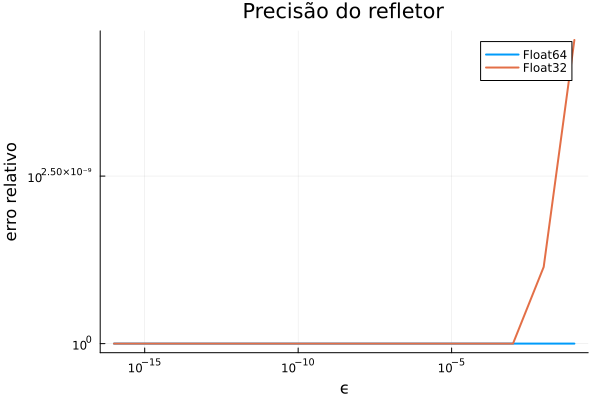

In [25]:
epss = 10.0 .^ (-1:-1:-16)

err64 = Float64[]
err32 = Float64[]

for ϵ in epss

    x64 = Float64[1.0,ϵ,ϵ]

    v,beta = reflector(x64)

    qx = apply_reflector(v,beta,x64)

    target = norm(x64)*[1.0,0.0,0.0]

    push!(
        err64,
        norm(qx-target)/norm(x64)
    )

    x32 = Float32[1.0f0,Float32(ϵ),Float32(ϵ)]

    v,beta = reflector(x32)

    qx = apply_reflector(v,beta,x32)

    target = norm(x32)*Float32[1,0,0]

    push!(
        err32,
        norm(qx-target)/norm(x32)
    )
end

plot(epss, err64 .+ 1,
    xscale=:log10,
    yscale=:log10,
    lw=2,
    label="Float64",
    xlabel="ϵ",
    ylabel="erro relativo",
    title="Precisão do refletor"
)

plot!(
    epss,
    err32 .+ 1,
    lw=2,
    label="Float32"
)

Como esperado, a função preserva a tipagem do vetor de entrada.

----------------------------------

#### Letra f)

In [3]:
function beta_from_v(v)

    vv = dot(v,v)

    if vv == zero(eltype(v))
        return zero(eltype(v))
    end

    return 2 / vv
end

beta_from_v (generic function with 1 method)

In [14]:
println("Float64")

x = Float64[1.0,1e-8,1e-8]

v,beta1 = reflector(x)

beta2 = beta_from_v(v)

println("beta via x = ", beta1)
println("beta via v = ", beta2)
println("erro = ", abs(beta1-beta2))

println()

println("Float32")

x = Float32[1.0,1e-8,1e-8]

v,beta1 = reflector(x)

beta2 = beta_from_v(v)

println("beta via x = ", beta1)
println("beta via v = ", beta2)
println("erro = ", abs(beta1-beta2))

Float64
beta via x = 9.999999999999998e15
beta via v = 9.999999999999998e15
erro = 0.0

Float32
beta via x = 1.0e16
beta via v = 1.0e16
erro = 0.0


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\elain\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\elain\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\elain\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\elain\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\elain\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\elain\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\elain\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


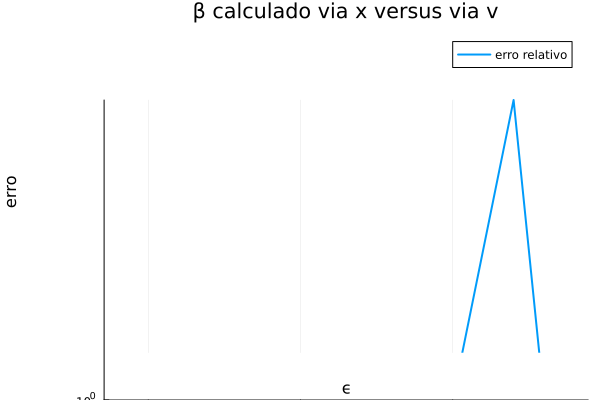

In [35]:
using PlotUtils

epss = 10.0 .^ (-1:-1:-16)

errs = Float64[]

for ϵ in epss

    x = Float64[1.0,ϵ,ϵ]

    v,beta_x = reflector(x)

    beta_v = 2/dot(v,v)

    push!(
        errs,
        abs(beta_x-beta_v)/abs(beta_x)
    )
end

plot(
    epss,
    errs .+ 1,
    xscale=:log10,
    yscale=:log10,
    lw=2,
    label="erro relativo",
    xlabel="ϵ",
    ylabel="erro",
    title="β calculado via x versus via v"
)

Ao repetir os testes, notamos que o erro residual entre calcular $\beta$ da primeira forma e usar $calc\_beta(v)$ fica na casa de $10^{-16}$ para $\texttt{Float64}$ e $10^{-7}$ para $\texttt{Float32}$. Observamos que não há muita diferença ao calcular $\beta$ a partir de $x$ ou apenas de $v$, mesmo com $x$ quase alinhado com $e_1$.

----------------------------------------

#### Letra g)

In [5]:
function reflector_naive(x)

    nx = norm(x)

    v = copy(x)

    v[1] -= nx

    beta = 2 / dot(v,v)

    return v,beta
end

reflector_naive (generic function with 1 method)

Experimento de condicionamento: Tomar vetores quase paralelos a $e_1$

In [12]:
println("eps        erro_relativo")

for k in 1:15

    eps = 10.0^(-k)

    x = Float64[1.0, eps, eps]

    v_naive,_ = reflector_naive(x)

    v_stable,_ = reflector(x)

    err =
        norm(v_naive - v_stable) /
        norm(v_stable)

    println(eps,"   ",err)
end

eps        erro_relativo
0.1   2.3248583572303497e-16
0.010000000000000002   6.7721960739557365e-15
0.001   8.995593644402822e-14
0.0001   7.618871003239476e-14
1.0e-5   5.854163260782064e-13
1.0e-6   6.286220497833137e-11
1.0000000000000001e-7   5.6517477884539856e-11
1.0e-8   7.071067811865475e-9
1.0e-9   7.071067811865476e-10
1.0e-10   7.071067811865475e-11
1.0e-11   7.071067811865475e-12
1.0000000000000002e-12   7.071067811865476e-13
1.0e-13   7.071067811865475e-14
1.0e-14   7.071067811865476e-15
1.0e-15   7.071067811865475e-16


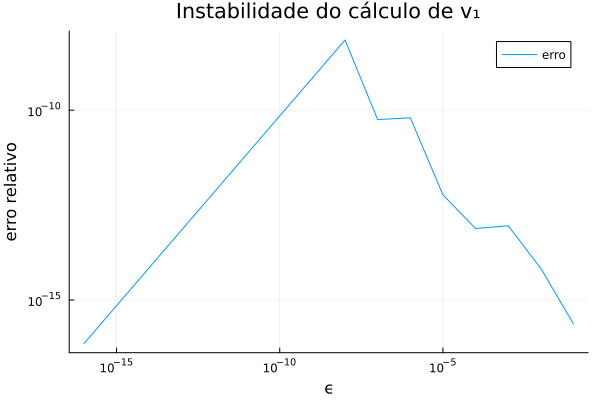

In [36]:
epss = Float64[]
errs = Float64[]

for k in 1:16

    eps = 10.0^(-k)

    x = Float64[1.0, eps, eps]

    v_naive,_ = reflector_naive(x)

    v_stable,_ = reflector(x)

    err =
        norm(v_naive - v_stable) /
        norm(v_stable)

    push!(epss, eps)
    push!(errs, err)
end

plot(
    epss,
    errs,
    xscale=:log10,
    yscale=:log10,
    xlabel="ϵ",
    ylabel="erro relativo",
    label="erro",
    title="Instabilidade do cálculo de v₁"
)

Quando $x \approx \|x\|e_1$ e $x_1 > 0$, a fórmula $v_1 = x_1 - \|x\|$ sofre cancelamento catastrófico. Esse é o motivo de $v_1$ ser relativamente mal-condicionado neste cenário. Inspirado na fórmula algébrica da racionalização de $\beta$, podemos propor outra fórmula para calcular $v_1$. Multiplicando $v_1$ pelo conjugado:
$$ v_1 = \frac{(x_1 - \|x\|)(x_1 + \|x\|)}{x_1 + \|x\|} = \frac{x_1^2 - \|x\|^2}{x_1 + \|x\|} $$
Como $\|x\|^2 = x_1^2 + \|y\|^2$, temos que $x_1^2 - \|x\|^2 = -\|y\|^2$. Logo, a fórmula estabilizada é:
$$ v_1 = \frac{-\|y\|^2}{x_1 + \|x\|} $$
Essa fórmula garante o cálculo preciso de $v_1$, refletindo $x$ em $\|x\|e_1$ sem ser sensível ao cancelamento. O objetivo de refletir um vetor com $x_1 > 0$ na primeira coordenada positiva é garantir que $R$ terá elementos positivos na diagonal.

Tamanho de $|v_1|$ quando $x = (1, \epsilon, \epsilon)$

In [31]:
function plot_v1_size()

    epss = 10.0 .^ (-1:-1:-16)

    vals = Float64[]

    for ϵ in epss

        x = Float64[1.0,ϵ,ϵ]

        nx = norm(x)

        v1 = 1.0 - nx

        push!(vals,abs(v1))
    end

    plot(
        epss,
        vals .+ 1,
        xscale=:log10,
        yscale=:log10,
        lw=2,
        label="|v₁|",
        xlabel="ϵ",
        ylabel="|v₁|",
        title="Magnitude de v₁"
    )
end

plot_v1_size (generic function with 1 method)

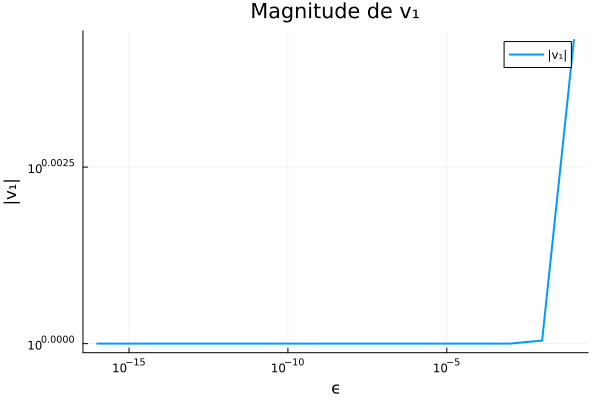

In [32]:
plot_v1_size()

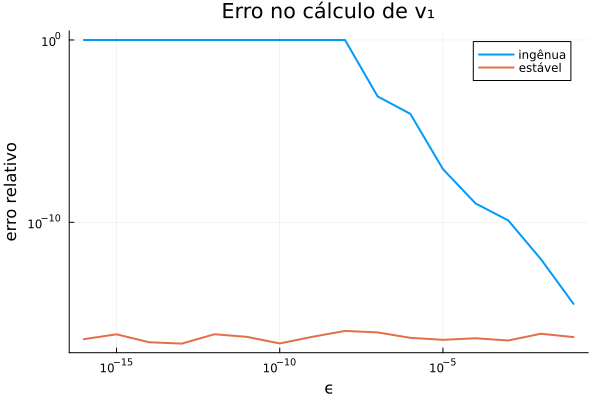

In [34]:
epss = 10.0 .^ (-1:-1:-16)

err_naive = Float64[]
err_stable = Float64[]

for ϵ in epss

    xb = BigFloat[1, BigFloat(ϵ), BigFloat(ϵ)]

    nxb = norm(xb)

    vtrue =
        BigFloat(1) - nxb

    x = Float64[1.0,ϵ,ϵ]

    nx = norm(x)

    v_naive =
        1.0 - nx

    v_stable =
        -(2*ϵ^2)/(nx + 1.0)

    push!(
        err_naive,
        abs((BigFloat(v_naive)-vtrue)/vtrue)
    )

    push!(
        err_stable,
        abs((BigFloat(v_stable)-vtrue)/vtrue)
    )
end
plot(
    epss,
    err_naive,
    xscale=:log10,
    yscale=:log10,
    lw=2,
    label="ingênua",
    xlabel="ϵ",
    ylabel="erro relativo",
    title="Erro no cálculo de v₁"
)

plot!(
    epss,
    err_stable,
    lw=2,
    label="estável"
)
 